In [1]:
import pandas as pd
import numpy as np
import re

# df = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/5000_Posts_Annotations - Combined_Dataset.csv")
DATA_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/5000_Posts_Annotations - Combined_Dataset.csv"   
TEXT_COL = "body"                          
TAGS_COL = "Tags"

df = pd.read_csv(DATA_PATH)

# Clean + split tags
df[TAGS_COL] = df[TAGS_COL].fillna("").astype(str).str.strip()
df["tag_list"] = df[TAGS_COL].apply(lambda x: [t.strip() for t in x.split(",")] if x != "" else [])

# Explode: one (post, tag) per row
df_exploded = df.explode("tag_list").rename(columns={"tag_list": "TW_category"})
df_exploded = df_exploded[df_exploded["TW_category"].notna()]
df_exploded["TW_category"] = df_exploded["TW_category"].astype(str).str.strip()

# OPTIONAL: remove empty tags
df_exploded = df_exploded[df_exploded["TW_category"] != ""]

# Show counts
print(df_exploded["TW_category"].value_counts())

TW_category
Mental Health     3550
Pregnancy         2652
Medical           1815
Abuse             1703
Sexual             918
Not Applicable     862
Discrimination     526
Aggression         196
Name: count, dtype: int64


In [2]:
MAIN_TW = [
    "Mental Health",
    "Pregnancy",
    "Medical",
    "Abuse",
    "Sexual",
    "Discrimination",
    "Aggression"
]

CONTROL = "Not Applicable"

df_tw_main = df_exploded[df_exploded["TW_category"].isin(MAIN_TW)].copy()
df_na = df_exploded[df_exploded["TW_category"] == CONTROL].copy()

print("Main TW rows:", len(df_tw_main))
print("Not Applicable rows:", len(df_na))
print(df_tw_main["TW_category"].value_counts())

Main TW rows: 11360
Not Applicable rows: 862
TW_category
Mental Health     3550
Pregnancy         2652
Medical           1815
Abuse             1703
Sexual             918
Discrimination     526
Aggression         196
Name: count, dtype: int64


In [3]:
def tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

## Emotion Analysis - NRC (Plutchik Emotions)

In [4]:
from collections import defaultdict

NRC_PATH = "/home/ubuntu/TW_MultiLabel_SMP/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"  # update if needed

nrc = pd.read_csv(
    NRC_PATH,
    sep="\t",
    header=None,
    names=["word", "emotion", "association"]
)

nrc = nrc[nrc["association"] == 1]

emotion_lex = defaultdict(set)
for _, row in nrc.iterrows():
    emotion_lex[row["emotion"]].add(row["word"])

EMOTIONS = ["anger","fear","sadness","disgust","anticipation","trust","joy","surprise"]
print("Loaded NRC emotions:", EMOTIONS)

Loaded NRC emotions: ['anger', 'fear', 'sadness', 'disgust', 'anticipation', 'trust', 'joy', 'surprise']


In [5]:
def emotion_features(text):
    tokens = tokenize(text)
    n = max(len(tokens), 1)
    return {emo: sum(t in emotion_lex[emo] for t in tokens) / n for emo in EMOTIONS}

emo_df = df_tw_main[TEXT_COL].apply(emotion_features).apply(pd.Series)
df_tw_main = pd.concat([df_tw_main, emo_df], axis=1)

emotion_by_tw = df_tw_main.groupby("TW_category")[EMOTIONS].mean()
emotion_by_tw

,anger,fear,sadness,disgust,anticipation,trust,joy,surprise
TW_category,,,,,,,,
Abuse,0.015303,0.018493,0.018634,0.012386,0.019171,0.025910,0.015271,0.007182
Aggression,0.018130,0.021245,0.021378,0.014272,0.019755,0.025415,0.015464,0.007769
Discrimination,0.015541,0.025265,0.024899,0.016786,0.019358,0.028159,0.016337,0.007575
Medical,0.009949,0.028559,0.029134,0.018637,0.021519,0.024986,0.016232,0.007707
Mental Health,0.013215,0.023386,0.024820,0.015546,0.021340,0.025940,0.017498,0.007892
Pregnancy,0.011193,0.027642,0.029145,0.018586,0.022560,0.026236,0.018798,0.008080
Sexual,0.013538,0.017504,0.017501,0.012103,0.021444,0.025605,0.016190,0.006785


## Pronoun Usage per TW Category

In [6]:
FIRST = {"i","me","my","mine","myself"}
SECOND = {"you","your","yours","yourself"}
THIRD = {"he","she","they","them","his","her","their","theirs"}

def pronoun_features(text):
    tokens = tokenize(text)
    n = max(len(tokens), 1)
    return {
        "first_person": sum(t in FIRST for t in tokens) / n,
        "second_person": sum(t in SECOND for t in tokens) / n,
        "third_person": sum(t in THIRD for t in tokens) / n,
    }

pro_df = df_tw_main[TEXT_COL].apply(pronoun_features).apply(pd.Series)
df_tw_main = pd.concat([df_tw_main, pro_df], axis=1)

pron_by_tw = df_tw_main.groupby("TW_category")[["first_person","second_person","third_person"]].mean()
pron_by_tw

,first_person,second_person,third_person
TW_category,,,
Abuse,0.105564,0.004056,0.035509
Aggression,0.108186,0.003505,0.042124
Discrimination,0.092947,0.007431,0.030549
Medical,0.089756,0.004747,0.012934
Mental Health,0.099547,0.004693,0.024043
Pregnancy,0.091547,0.005778,0.016070
Sexual,0.106757,0.003555,0.035516


## Verb Tense per TW Category

In [25]:
import spacy
nlp = spacy.load("en_core_web_sm")

def tense_features(text):
    doc = nlp(str(text))
    past = present = future = 0

    for tok in doc:
        if tok.pos_ == "VERB":
            if "Tense=Past" in tok.morph:
                past += 1
            elif "Tense=Pres" in tok.morph:
                present += 1

        # simple future markers (lightweight)
        if tok.lower_ in {"will", "gonna"}:
            future += 1

    total = max(past + present + future, 1)
    return {
        "past": past / total,
        "present": present / total,
        "future": future / total
    }

tense_df = df_tw_main[TEXT_COL].apply(tense_features).apply(pd.Series)
df_tw_main = pd.concat([df_tw_main, tense_df], axis=1)

tense_by_tw = df_tw_main.groupby("TW_category")[["past","present","future"]].mean()
tense_by_tw

,past,present,future
TW_category,,,
Abuse,0.539487,0.447343,0.010234
Medical,0.510262,0.470527,0.015905
Mental Health,0.498549,0.487169,0.013719
Pregnancy,0.474073,0.503788,0.017614
Sexual,0.560684,0.429582,0.008644


## Bodily / Sensory Language per TW Category

In [26]:
BODY_WORDS = {
    "pain","hurt","blood","bleeding","cramps","injury","wound","bruise",
    "stomach","head","chest","throat","skin","body","vomit","nausea"
}

def body_ratio(text):
    tokens = tokenize(text)
    return sum(t in BODY_WORDS for t in tokens) / max(len(tokens), 1)

df_tw_main["body_ratio"] = df_tw_main[TEXT_COL].apply(body_ratio)

body_by_tw = df_tw_main.groupby("TW_category")["body_ratio"].mean()
body_by_tw

TW_category
Abuse            0.002294
Medical          0.010335
Mental Health    0.005150
Pregnancy        0.007557
Sexual           0.003050
Name: body_ratio, dtype: float64

## TW vs NA

In [7]:
# Create a combined TW dataframe (all main TW rows) + NA rows
df_control = pd.concat([
    df_tw_main.assign(group="TW"),
    df_na.assign(group="Not Applicable")
], axis=0)

# If NRC/pronoun/tense/body weren’t computed for df_na yet, compute them quickly:

# emotions for NA
emo_na = df_na[TEXT_COL].apply(emotion_features).apply(pd.Series)
pro_na = df_na[TEXT_COL].apply(pronoun_features).apply(pd.Series)
# ten_na = df_na[TEXT_COL].apply(tense_features).apply(pd.Series)
# body_na = df_na[TEXT_COL].apply(body_ratio)

df_na_feats = pd.concat([df_na, emo_na, pro_na], axis=1)
# df_na_feats["body_ratio"] = body_na
df_na_feats["group"] = "Not Applicable"

df_tw_feats = df_tw_main.copy()
df_tw_feats["group"] = "TW"

df_control_feats = pd.concat([df_tw_feats, df_na_feats], axis=0)

control_emotions = df_control_feats.groupby("group")[EMOTIONS].mean()
control_pronouns = df_control_feats.groupby("group")[["first_person","second_person","third_person"]].mean()
# control_tense = df_control_feats.groupby("group")[["past","present","future"]].mean()
# control_body = df_control_feats.groupby("group")[["body_ratio"]].mean()

control_emotions, control_pronouns


(                   anger      fear   sadness   disgust  anticipation  \
 group                                                                  
 Not Applicable  0.014045  0.016382  0.017113  0.011409      0.018664   
 TW              0.012753  0.024048  0.024944  0.016033      0.021218   
 
                    trust       joy  surprise  
 group                                         
 Not Applicable  0.025585  0.016719  0.008051  
 TW              0.025919  0.017071  0.007694  ,
                 first_person  second_person  third_person
 group                                                    
 Not Applicable      0.076250       0.006899      0.032092
 TW                  0.097443       0.004874      0.023666)

# Plots

## Radar Plot

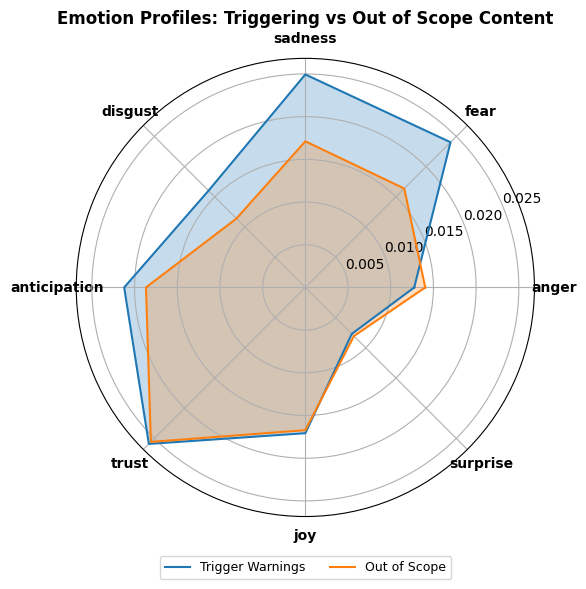

In [47]:
import numpy as np
import matplotlib.pyplot as plt

labels = EMOTIONS
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

def radar_vals(row):
    vals = row.values.tolist()
    return vals + vals[:1]

tw_vals = radar_vals(control_emotions.loc["TW"])
na_vals = radar_vals(control_emotions.loc["Not Applicable"])

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

ax.plot(angles, tw_vals, label="Trigger Warnings")
ax.fill(angles, tw_vals, alpha=0.25)

ax.plot(angles, na_vals, label="Out of Scope")
ax.fill(angles, na_vals, alpha=0.25)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
ax.set_title("Emotion Profiles: Triggering vs Out of Scope Content",
    fontweight="bold")
# ax.legend(loc="upper right")
legend = ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),  
    ncol=2,                      
    fontsize=9,                  
    frameon=True            
)
plt.tight_layout()
plt.savefig("fig_emotion_radar_tw_vs_na.pdf", bbox_inches="tight")
plt.show()

In [31]:
emotion_by_tw.index
tense_by_tw.index
pron_by_tw.index
body_by_tw.index

Index(['Abuse', 'Medical', 'Mental Health', 'Pregnancy', 'Sexual'], dtype='object', name='TW_category')

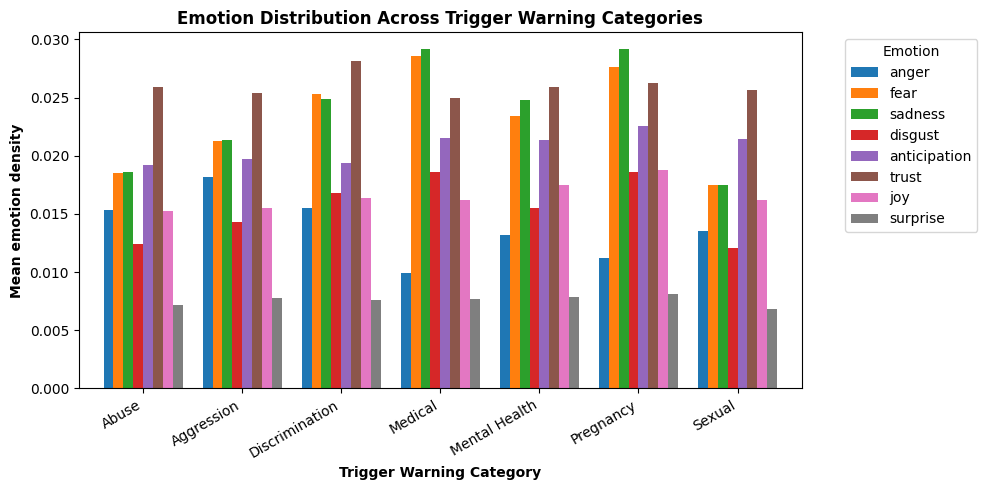

In [14]:
import matplotlib.pyplot as plt

emotion_by_tw.plot(
    kind="bar",
    figsize=(10,5),
    width=0.8
)

plt.ylabel("Mean emotion density", fontweight="bold")
plt.xlabel("Trigger Warning Category", fontweight="bold")
plt.title("Emotion Distribution Across Trigger Warning Categories", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Emotion", bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.savefig(
    "emotion_by_tw.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

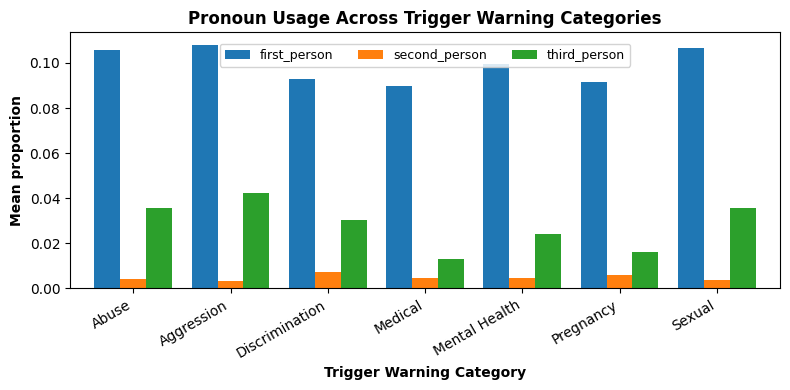

In [46]:
ax = pron_by_tw.plot(kind="bar", figsize=(8,4), width=0.8)

ax.set_ylabel("Mean proportion", fontweight="bold")
ax.set_xlabel("Trigger Warning Category", fontweight="bold")
ax.set_title("Pronoun Usage Across Trigger Warning Categories", fontweight="bold")

ax.tick_params(axis="x", rotation=30)
for t in ax.get_xticklabels():
    t.set_ha("right")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),   # inside, just under title
    ncol=3,                       # horizontal legend
    fontsize=9,
    frameon=True,
    fancybox=True,
    framealpha=0.85
)


plt.tight_layout()
plt.savefig("pron_by_tw.pdf", format="pdf", bbox_inches="tight")
plt.show()

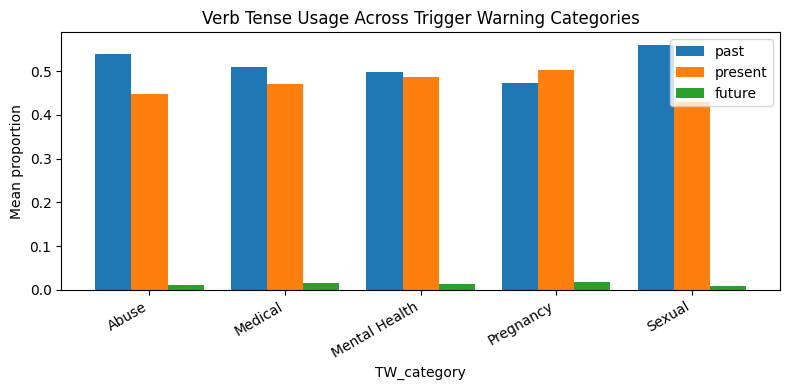

In [39]:
tense_by_tw.plot(
    kind="bar",
    figsize=(8,4),
    width=0.8
)

plt.ylabel("Mean proportion")
plt.title("Verb Tense Usage Across Trigger Warning Categories")
plt.xticks(rotation=30, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.savefig(
    "tense_by_tw.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

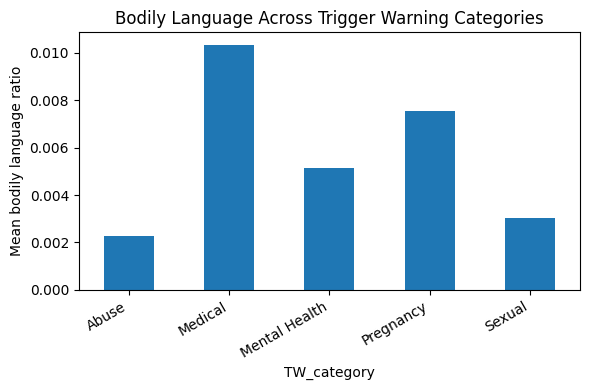

In [40]:
body_by_tw.plot(
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.ylabel("Mean bodily language ratio")
plt.title("Bodily Language Across Trigger Warning Categories")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    "body_by_tw.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

## Examples for plots

In [12]:
emo_feats = df[TEXT_COL].apply(emotion_features).apply(pd.Series)
df_emo = pd.concat([df, emo_feats], axis=1)

In [13]:
trust_threshold = df_emo["trust"].quantile(0.75)

In [16]:
type(df_emo["tag_list"].iloc[0])

list

In [21]:
from collections import defaultdict

def load_nrc(path):
    lex = defaultdict(set)
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()   # <-- KEY FIX
            if len(parts) != 3:
                continue  # skip malformed lines safely
            word, emotion, val = parts
            if val == "1":
                lex[word].add(emotion)
    return dict(lex)

NRC_PATH = "/home/ubuntu/TW_MultiLabel_SMP/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"
nrc_lexicon = load_nrc(NRC_PATH)

print("Loaded emotions:",
      sorted({e for v in nrc_lexicon.values() for e in v}))

Loaded emotions: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust']


In [25]:
# ============================================================
# UPDATED: Qualitative Example Selection + Emotion Attribution
# Fixes:
#   ✅ Selects LONGER posts (min token length) so examples aren’t tiny questions
#   ✅ Shows FULL NA text (no notebook truncation issues)
#   ✅ Saves BOTH examples to a single PDF + a DOCX for easy copy/paste
#   ✅ Keeps inline/sentence highlighting in-notebook (optional)
#
# Assumptions:
#   df_emo has columns: "body", "tag_list", plus EMOTIONS columns
#   tag_list is a Python list (you confirmed)
#   EMOTIONS = ["anger","fear","sadness","disgust","anticipation","trust","joy","surprise"]
#   nrc_lexicon is already loaded (word -> set(emotions))
# ============================================================

import re
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import display, HTML
import html as html_escape

# ----------------------------
# 0) Sanity checks
# ----------------------------
assert "tag_list" in df_emo.columns, "df_emo must have a 'tag_list' column"
assert "body" in df_emo.columns, "df_emo must have a 'body' column"
for e in EMOTIONS:
    assert e in df_emo.columns, f"Missing emotion column: {e}"
assert isinstance(df_emo["tag_list"].iloc[0], list), "tag_list must be a list per row"
assert isinstance(nrc_lexicon, dict), "nrc_lexicon must be a dict[word] -> set(emotions)"

# ----------------------------
# 1) Create TW vs NA flags
# ----------------------------
df_emo["is_NA"] = df_emo["tag_list"].apply(lambda tags: tags == ["Not Applicable"])
df_emo["is_TW"] = ~df_emo["is_NA"]

# ----------------------------
# 2) Add length filter to avoid short posts inflating emotion densities
# ----------------------------
df_emo["n_tokens"] = df_emo["body"].fillna("").apply(lambda x: len(re.findall(r"\b\w+\b", x)))
MIN_TOKENS = 80   # <- change to 50/100 depending on how long you want the examples

# ----------------------------
# 3) Thresholds (robust)
# ----------------------------
trust_thr = df_emo["trust"].quantile(0.75)

# ----------------------------
# 4) High-trust pools WITH LENGTH FILTER
# ----------------------------
tw_trust = df_emo[
    (df_emo["is_TW"]) &
    (df_emo["trust"] >= trust_thr) &
    (df_emo["n_tokens"] >= MIN_TOKENS)
].copy()

na_trust = df_emo[
    (df_emo["is_NA"]) &
    (df_emo["trust"] >= trust_thr) &
    (df_emo["n_tokens"] >= MIN_TOKENS)
].copy()

# If NA becomes too small after filtering, relax token threshold for NA only:
if len(na_trust) < 5:
    na_trust = df_emo[
        (df_emo["is_NA"]) &
        (df_emo["trust"] >= trust_thr) &
        (df_emo["n_tokens"] >= max(20, MIN_TOKENS // 2))
    ].copy()

print("Candidate pool sizes:",
      "TW=", len(tw_trust),
      "NA=", len(na_trust))

# ----------------------------
# 5) Contrast score (captures "TW-ness" beyond trust)
# ----------------------------
contrast_emotions = ["fear", "sadness", "anticipation", "disgust"]
tw_trust["contrast_score"] = tw_trust[contrast_emotions].sum(axis=1)
na_trust["contrast_score"] = na_trust[contrast_emotions].sum(axis=1)

# ----------------------------
# 6) Pick examples (reproducible)
# ----------------------------
tw_example = tw_trust.sort_values(["contrast_score", "trust"], ascending=False).iloc[0]
na_example = na_trust.sort_values(["contrast_score", "trust"], ascending=[True, False]).iloc[0]

# ============================================================
# DISPLAY HELPERS (FULL TEXT)
# ============================================================

def show_example_full(row, title):
    print(f"\n=== {title} ===")
    print("Tags:", row["tag_list"])
    print(f"Token length: {row['n_tokens']}")
    print("\nFULL TEXT:\n")
    print(row["body"] if row["body"] is not None else "")
    print("\nEmotions:")
    print(row[["trust","fear","sadness","anticipation","disgust","anger","joy","surprise"]])

show_example_full(tw_example, "TW example: high trust + higher other emotions")
show_example_full(na_example, "NA example: high trust + low other emotions")

# ============================================================
# OPTIONAL: In-notebook highlighting
# ============================================================

def split_sentences(text: str):
    text = (text or "").strip()
    if not text:
        return []
    return re.split(r'(?<=[.!?])\s+|\n+', text)

def sentence_emotion_hits(sent: str, nrc_lexicon, emotions_set):
    words = re.findall(r"\b[\w']+\b", sent.lower())
    hits = []
    for w in words:
        if w in nrc_lexicon:
            for e in nrc_lexicon[w]:
                if e in emotions_set:
                    hits.append((w, e))
    return hits

def render_sentences_with_emotions(text, nrc_lexicon, emotions=EMOTIONS, top_k=8):
    emotions_set = set(emotions)
    sents = split_sentences(text)
    rows = []
    for s in sents:
        hits = sentence_emotion_hits(s, nrc_lexicon, emotions_set)
        if hits:
            emo_counts = Counter([e for _, e in hits])
            word_map = defaultdict(set)
            for w, e in hits:
                word_map[w].add(e)
            rows.append((s, emo_counts, word_map))

    if not rows:
        display(HTML("<b>No NRC emotion words found in this text.</b>"))
        return

    rows.sort(key=lambda x: sum(x[1].values()), reverse=True)
    rows = rows[:top_k] if top_k else rows

    html = ["<div style='font-family: ui-sans-serif; line-height:1.5'>"]
    for i, (sent, emo_counts, word_map) in enumerate(rows, 1):
        badges = " ".join([
            f"<span style='padding:2px 6px;border:1px solid #ddd;border-radius:10px;margin-right:6px'>"
            f"{e}: {emo_counts.get(e,0)}</span>"
            for e in emotions if emo_counts.get(e,0) > 0
        ])
        mapping = "; ".join([
            f"<code>{w}</code>→{','.join(sorted(list(es)))}"
            for w, es in sorted(word_map.items(), key=lambda t: t[0])
        ])
        html.append(
            f"<div style='margin:10px 0;padding:10px;border:1px solid #eee;border-radius:10px'>"
            f"<div><b>Sentence {i}</b></div>"
            f"<div style='margin:6px 0'>{html_escape.escape(sent)}</div>"
            f"<div style='margin:6px 0'>{badges}</div>"
            f"<div style='color:#555'><b>Matched words:</b> {mapping}</div>"
            f"</div>"
        )
    html.append("</div>")
    display(HTML("".join(html)))

EMO_COLORS = {
    "anger": "#ffdddd",
    "fear": "#fff0cc",
    "sadness": "#dde8ff",
    "disgust": "#e6ddff",
    "anticipation": "#ddffea",
    "trust": "#ddfff7",
    "joy": "#fff7cc",
    "surprise": "#f0f0f0",
}

def highlight_full_text(text, nrc_lexicon, focus_emotions=None):
    emotions_set = set(focus_emotions) if focus_emotions else set(EMOTIONS)

    parts = re.findall(r"\b[\w']+\b|\W+", text or "")
    out = ["<div style='white-space: pre-wrap; font-family: ui-sans-serif; line-height:1.6'>"]

    for p in parts:
        if re.match(r"\b[\w']+\b", p):
            w = p.lower()
            if w in nrc_lexicon:
                emos = sorted([e for e in nrc_lexicon[w] if e in emotions_set])
                if emos:
                    bg = EMO_COLORS.get(emos[0], "#ffffcc")
                    tooltip = ", ".join(emos)
                    out.append(
                        f"<span title='{tooltip}' "
                        f"style='background:{bg}; padding:1px 3px; border-radius:4px; border:1px solid #ddd'>"
                        f"{html_escape.escape(p)}</span>"
                    )
                else:
                    out.append(html_escape.escape(p))
            else:
                out.append(html_escape.escape(p))
        else:
            out.append(html_escape.escape(p))

    out.append("</div>")

    legend_emotions = focus_emotions if focus_emotions else EMOTIONS
    legend = " ".join([
        f"<span style='background:{EMO_COLORS.get(e,'#ffffcc')}; padding:2px 6px; border:1px solid #ddd; "
        f"border-radius:8px; margin-right:6px'>{e}</span>"
        for e in legend_emotions
    ])

    display(HTML(f"<div style='margin-bottom:10px'>{legend}</div>" + "".join(out)))

focus = ["trust", "fear", "sadness", "anticipation", "disgust"]

print("\n--- TW: Inline highlighted (hover words for emotion tags) ---")
highlight_full_text(tw_example["body"], nrc_lexicon, focus_emotions=focus)

print("\n--- NA: Inline highlighted (hover words for emotion tags) ---")
highlight_full_text(na_example["body"], nrc_lexicon, focus_emotions=focus)

print("\n--- TW: Top emotion-bearing sentences ---")
render_sentences_with_emotions(tw_example["body"], nrc_lexicon, top_k=10)

print("\n--- NA: Top emotion-bearing sentences ---")
render_sentences_with_emotions(na_example["body"], nrc_lexicon, top_k=10)

# ============================================================
# EXPORT: Save BOTH examples to DOCX + PDF for easy copy/paste
# ============================================================

# ---- DOCX export ----
from docx import Document

def export_examples_docx(path, tw_row, na_row):
    doc = Document()
    doc.add_heading("Qualitative Examples: High-Trust TW vs High-Trust NA", level=1)

    def add_block(title, row):
        doc.add_heading(title, level=2)
        doc.add_paragraph(f"Tags: {', '.join(row['tag_list'])}")
        doc.add_paragraph(f"Token length: {row['n_tokens']}")
        emo_line = ", ".join([f"{e}: {row[e]:.6f}" for e in EMOTIONS])
        doc.add_paragraph(f"Emotion scores: {emo_line}")
        doc.add_paragraph("Post text:")
        doc.add_paragraph(row["body"] or "")

    add_block("TW example (high trust + higher other emotions)", tw_row)
    add_block("NA example (high trust + low other emotions)", na_row)

    doc.save(path)

DOCX_OUT = "qual_examples_tw_vs_na.docx"
export_examples_docx(DOCX_OUT, tw_example, na_example)
print("Saved DOCX:", DOCX_OUT)

# ---- PDF export ----
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, PageBreak
from reportlab.lib.pagesizes import LETTER
from reportlab.lib.styles import getSampleStyleSheet

def export_examples_pdf(path, tw_row, na_row):
    styles = getSampleStyleSheet()
    doc = SimpleDocTemplate(path, pagesize=LETTER)
    story = []

    def add_block(title, row):
        story.append(Paragraph(f"<b>{title}</b>", styles["Heading2"]))
        story.append(Paragraph(f"<b>Tags:</b> {', '.join(row['tag_list'])}", styles["Normal"]))
        story.append(Paragraph(f"<b>Token length:</b> {row['n_tokens']}", styles["Normal"]))
        emo_line = ", ".join([f"{e}: {row[e]:.6f}" for e in EMOTIONS])
        story.append(Paragraph(f"<b>Emotion scores:</b> {emo_line}", styles["Normal"]))
        story.append(Spacer(1, 10))

        text = (row["body"] or "")
        # Escape for ReportLab's Paragraph
        text = text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;").replace("\n", "<br/>")
        story.append(Paragraph(f"<b>Post text:</b><br/>{text}", styles["Normal"]))
        story.append(PageBreak())

    story.append(Paragraph("Qualitative Examples: High-Trust TW vs High-Trust NA", styles["Title"]))
    story.append(Spacer(1, 12))
    add_block("TW example (high trust + higher other emotions)", tw_row)
    add_block("NA example (high trust + low other emotions)", na_row)

    doc.build(story)

PDF_OUT = "qual_examples_tw_vs_na.pdf"
export_examples_pdf(PDF_OUT, tw_example, na_example)
print("Saved PDF:", PDF_OUT)

# Also save as a CSV for convenience
CSV_OUT = "qual_examples_tw_vs_na.csv"
pd.DataFrame([
    {"which": "TW", "tags": tw_example["tag_list"], "n_tokens": tw_example["n_tokens"], "text": tw_example["body"], **{e: tw_example[e] for e in EMOTIONS}},
    {"which": "NA", "tags": na_example["tag_list"], "n_tokens": na_example["n_tokens"], "text": na_example["body"], **{e: na_example[e] for e in EMOTIONS}},
]).to_csv(CSV_OUT, index=False)
print("Saved CSV:", CSV_OUT)

Candidate pool sizes: TW= 864 NA= 222

=== TW example: high trust + higher other emotions ===
Tags: ['Medical', 'Pregnancy']
Token length: 87

FULL TEXT:

It has been 2 weeks since I have taken the medical abortion pills and after the first week I just stopped feeling any pain still bleeding but not too heavy and light but suddenly I’ve started feeling really bad pains again in my thighs and pelvic area exactly the pains I was going through when the abortion was happening is this normal to still feel pain even tho I went a week without any pain?? I started feeling pain yesterday as well and now today again

Emotions:
trust           0.045977
fear            0.137931
sadness         0.126437
anticipation    0.045977
disgust          0.08046
anger           0.045977
joy             0.034483
surprise        0.045977
Name: 14, dtype: object

=== NA example: high trust + low other emotions ===
Tags: ['Not Applicable']
Token length: 302

FULL TEXT:

Location: Georgia the US state not he coun


--- NA: Inline highlighted (hover words for emotion tags) ---



--- TW: Top emotion-bearing sentences ---



--- NA: Top emotion-bearing sentences ---


Saved DOCX: qual_examples_tw_vs_na.docx
Saved PDF: qual_examples_tw_vs_na.pdf
Saved CSV: qual_examples_tw_vs_na.csv
